# Joint Ensemble Member Inference (Discharge × Total Nitrogen)

Propagate **joint** (discharge, total_nitrogen) ensemble uncertainty through the saved
Random Forest bloom classifier. For each of the 4 UQ methods (bootstrap, GLUE, EnKF, LPU),
sample 5 random same-method `(discharge_member, tn_member)` pairs and feed both variables
simultaneously into the RF feature frame. Produces the same 4 output artifacts as
`discharge/notebooks/06_ensemble_member_inference.ipynb` but reflects joint uncertainty
in both variables rather than marginal uncertainty in one.

**Run location:** workspace root (`Senior_Project_Final/`) — see import-strategy cell below.

## Import strategy — notebook-only, inline helpers

This notebook **does not import from** `red_tide_reanalysis` (neither sub-project's copy).
All helpers are **inlined** in the cell below.

**Why:**
- Both `discharge/src/` and `total_nitrogen/src/` ship a Python package named
  `red_tide_reanalysis` — only one can be installed at a time. Inlining sidesteps the collision entirely.
- `sys.path.insert(0, os.path.abspath("src"))` is fragile: it resolves against the
  Jupyter kernel's CWD, which breaks under papermill or when the notebook is opened
  from a parent directory. This notebook avoids that pattern.
- The two helpers total ~20 lines — the cost of inlining is low, and keeps
  the deliverable to notebook-only (no workspace-level Python package).

**Drift warning:** if `discharge/src/red_tide_reanalysis/ml/feature_builder.py` or
`discharge/src/red_tide_reanalysis/ml/inference.py` ever change upstream (new feature
column, new scaling factor, new preprocessing step), the inlined copies below **must
be manually reconciled**. The source-comment citations in the helpers cell serve as
tripwires at code review.

**Run location:** workspace root. Paths in the USER
CONFIGURATION cell above are relative to this CWD; the existence assertions there
fire with actionable errors if the notebook is launched from the wrong directory.

In [1]:
import os as _os
from pathlib import Path as _Path
# nbconvert executes notebooks with the kernel CWD set to the notebook's directory.
# When this notebook lives in notebooks/, Path('discharge/...') would resolve from
# notebooks/ instead of the workspace root. Detect and correct automatically.
_cwd = _Path.cwd()
if _cwd.name == "notebooks" and (_cwd.parent / "discharge").is_dir():
    _os.chdir(_cwd.parent)  # move to workspace root (Senior_Project_Final/)
del _os, _Path, _cwd  # clean up after ourselves

# ── USER CONFIGURATION ────────────────────────────────────────────────────────────────────────────────
# Single source of truth for every configurable path and run parameter.
# All paths are resolved relative to the WORKSPACE ROOT (Senior_Project_Final/).
# If run from a different CWD, the existence assertions below fire with actionable
# error messages.

from pathlib import Path

# ── Run parameters ────────────────────────────────────────────────────────────────────────
METHODS              = ["bootstrap", "glue", "enkf", "lpu"]     # authoritative order
N_PAIRS_PER_METHOD   = 5
PAIRING_SEED         = 42
TEST_CUTOFF          = "2019-01-01"                             # matches discharge/06 template
SAVE_OUTPUTS         = True

# ── Input paths ──────────────────────────────────────────
DISCHARGE_ENSEMBLE_DIR = Path("discharge/notebooks/data/outputs/ensembles")
TN_ENSEMBLE_DIR        = Path("total_nitrogen/output/ensembles")
MODEL_PATH             = Path("discharge/models/rf_bloom_classifier.joblib")
SCALER_PATH            = Path("discharge/models/robust_scaler.joblib")
OBS_CSV                = Path("discharge/machineLearning/machineLearning/input/data_weekly_intepolated.csv")  # — note: "intepolated" spelling preserved from upstream

# ── Output paths ─────────────────────────────────────────────────────────────────────────
OUTPUT_DIR  = Path("output/joint")
FIGURES_DIR = OUTPUT_DIR / "figures"
CSV_DIR     = OUTPUT_DIR / "csv"

# ── Ensemble-file dicts ─────────────────────────────────────────────────────────────────────────
# Discharge filenames are NOT uniform — only bootstrap has "peace_river" in the name
# whereas glue/enkf/lpu do not. Explicit dict avoids brittle f-string reconstruction.
ENSEMBLE_FILES_DISCHARGE = {
    "bootstrap": "bootstrap_02296750_peace_river_discharge_members.csv",
    "glue":      "glue_02296750_discharge_members.csv",
    "enkf":      "enkf_02296750_discharge_members.csv",
    "lpu":       "lpu_02296750_discharge_members.csv",
}
# TN filenames ARE uniform: {method}_02296750_peace_river_total_nitrogen_members.csv
ENSEMBLE_FILES_TN = {
    "bootstrap": "bootstrap_02296750_peace_river_total_nitrogen_members.csv",
    "glue":      "glue_02296750_peace_river_total_nitrogen_members.csv",
    "enkf":      "enkf_02296750_peace_river_total_nitrogen_members.csv",
    "lpu":       "lpu_02296750_peace_river_total_nitrogen_members.csv",
}

# ── Path-existence assertions ─────────────────────────────────────────────────────────────────────────
assert MODEL_PATH.exists(), (
    f"Model not found: {MODEL_PATH.resolve()}\n"
    f"  → Run discharge/notebooks/00_serialize_model.ipynb to regenerate, or\n"
    f"    repoint MODEL_PATH at total_nitrogen/models/rf_bloom_classifier.joblib."
)
assert SCALER_PATH.exists(), (
    f"Scaler not found: {SCALER_PATH.resolve()}\n"
    f"  → Run discharge/notebooks/00_serialize_model.ipynb to regenerate, or\n"
    f"    repoint SCALER_PATH at total_nitrogen/models/robust_scaler.joblib."
)
assert DISCHARGE_ENSEMBLE_DIR.is_dir(), (
    f"Discharge ensemble directory not found: {DISCHARGE_ENSEMBLE_DIR.resolve()}\n"
    f"  → Run discharge/notebooks/{{01_bootstrap,02_glue,03_enkf,04_lpu}}_ci.ipynb to generate."
)
assert TN_ENSEMBLE_DIR.is_dir(), (
    f"Total-nitrogen ensemble directory not found: {TN_ENSEMBLE_DIR.resolve()}\n"
    f"  → Run total_nitrogen/{{01_bootstrap,02_glue,03_enkf,04_lpu}}_ci.ipynb to generate."
)
assert OBS_CSV.exists(), (
    f"Weekly-interpolated obs CSV not found: {OBS_CSV.resolve()}\n"
    f"  → Confirm the file lives under discharge/machineLearning/machineLearning/input/"
)

# Per-method ensemble CSV existence checks (8 files total — 4 discharge + 4 TN)
for method in METHODS:
    d_csv = DISCHARGE_ENSEMBLE_DIR / ENSEMBLE_FILES_DISCHARGE[method]
    assert d_csv.exists(), f"Missing discharge ensemble: {d_csv.resolve()}"
    t_csv = TN_ENSEMBLE_DIR / ENSEMBLE_FILES_TN[method]
    assert t_csv.exists(), f"Missing TN ensemble: {t_csv.resolve()}"

# ── Auto-create output subdirectories ─────────────────────────────────────────────────────────────────────────
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

# ── Resolution summary ─────────────────────────────────────────────────────────────────────────────────
print("USER CONFIGURATION resolved:")
print(f"  METHODS                  = {METHODS}")
print(f"  N_PAIRS_PER_METHOD       = {N_PAIRS_PER_METHOD}")
print(f"  PAIRING_SEED             = {PAIRING_SEED}")
print(f"  TEST_CUTOFF              = {TEST_CUTOFF}")
print(f"  DISCHARGE_ENSEMBLE_DIR   = {DISCHARGE_ENSEMBLE_DIR.resolve()}")
print(f"  TN_ENSEMBLE_DIR          = {TN_ENSEMBLE_DIR.resolve()}")
print(f"  MODEL_PATH               = {MODEL_PATH.resolve()}")
print(f"  SCALER_PATH              = {SCALER_PATH.resolve()}")
print(f"  OBS_CSV                  = {OBS_CSV.resolve()}")
print(f"  OUTPUT_DIR               = {OUTPUT_DIR.resolve()}")
print(f"  FIGURES_DIR              = {FIGURES_DIR.resolve()}  (auto-created)")
print(f"  CSV_DIR                  = {CSV_DIR.resolve()}  (auto-created)")


USER CONFIGURATION resolved:
  METHODS                  = ['bootstrap', 'glue', 'enkf', 'lpu']
  N_PAIRS_PER_METHOD       = 5
  PAIRING_SEED             = 42
  TEST_CUTOFF              = 2019-01-01
  DISCHARGE_ENSEMBLE_DIR   = discharge\notebooks\data\outputs\ensembles
  TN_ENSEMBLE_DIR          = total_nitrogen\output\ensembles
  MODEL_PATH               = discharge\models\rf_bloom_classifier.joblib
  SCALER_PATH              = discharge\models\robust_scaler.joblib
  OBS_CSV                  = discharge\machineLearning\machineLearning\input\data_weekly_intepolated.csv
  OUTPUT_DIR               = output\joint
  FIGURES_DIR              = output\joint\figures  (auto-created)
  CSV_DIR                  = output\joint\csv  (auto-created)


In [2]:
# ── INLINED HELPERS ─────────────────────────────────────────────────────────────────────────────
# These are verbatim copies of the two helpers from the discharge sub-project.
# See the markdown cell above for why they are inlined rather than imported.
# If upstream changes, reconcile manually.

from pathlib import Path
import numpy as np
import pandas as pd
import joblib


# source: discharge/src/red_tide_reanalysis/ml/feature_builder.py:13
# Unit conversion: WAM model ensemble output is in m³/s; obs CSV peace_discharge is in CFS.
# The RobustScaler was fit on CFS values — all discharge features fed to the model must be CFS.
M3S_TO_CFS: float = 35.3147


# source: discharge/src/red_tide_reanalysis/ml/feature_builder.py:18-25
# 15 features — exact order from ml.ipynb cell 10.
# The RF classifier and RobustScaler are version-locked to THIS order.
FEATURE_COLS: list[str] = [
    "kb", "kb_prev1", "kb_prev2",
    "zos", "salinity", "water_temp",
    "wind_speed", "wind_direction",
    "peace_discharge", "peace_TN", "peace_TP",
    "peace_discharge_prev1", "peace_TN_prev1", "peace_TP_prev1",
    "discharge_4w_avg",
]


# source: discharge/src/red_tide_reanalysis/ml/feature_builder.py:28-44
def resample_ensemble(ensemble_csv: Path) -> pd.DataFrame:
    """Read daily ensemble CSV (wide: date x member_NNNN), resample to W-MON.

    Parameters
    ----------
    ensemble_csv : Path
        Path to daily ensemble CSV with DatetimeIndex and member columns.

    Returns
    -------
    pd.DataFrame
        Shape (T_weeks, N_members) with Monday-anchored DatetimeIndex.
    """
    df = pd.read_csv(ensemble_csv, index_col=0, parse_dates=True)
    # CRITICAL: closed='left', label='left' — Sunday anchor silently corrupts lag features
    weekly = df.resample("W-MON", closed="left", label="left").mean()
    return weekly


# source: discharge/src/red_tide_reanalysis/ml/inference.py:11-43
def run_inference(
    members_array: np.ndarray,
    model_path: Path,
    scaler_path: Path,
) -> np.ndarray:
    """Run bloom probability inference for each ensemble member.

    CRITICAL: Only .transform() is called on the scaler. NEVER .fit_transform() —
    fit_transform() silently shifts the feature space with no error.

    Parameters
    ----------
    members_array : np.ndarray
        Shape (N, T_weeks, 15) feature array from build_features.
    model_path : Path
        Path to rf_bloom_classifier.joblib.
    scaler_path : Path
        Path to robust_scaler.joblib.

    Returns
    -------
    np.ndarray
        Shape (N, T_weeks) float32 bloom probabilities (class 1).
    """
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)

    N, T, F = members_array.shape
    proba = np.empty((N, T), dtype=np.float32)

    for i in range(N):
        X = members_array[i]              # (T, 15)
        Xs = scaler.transform(X)          # NEVER fit_transform
        proba[i] = model.predict_proba(Xs)[:, 1].astype(np.float32)

    return proba


print(f"Inlined helpers loaded: M3S_TO_CFS={M3S_TO_CFS}, FEATURE_COLS (15 entries), resample_ensemble, run_inference")


# source: adapted from discharge/src/red_tide_reanalysis/ml/feature_builder.py:47-94
def build_features_joint(
    d_weekly_df: pd.DataFrame,
    tn_weekly_df: pd.DataFrame,
    obs_csv: Path,
) -> np.ndarray:
    """Build joint (discharge + TN) feature array for N_PAIRS_PER_METHOD pairs.

    Parameters
    ----------
    d_weekly_df : pd.DataFrame
        Shape (T_d_weeks, N_pairs) - discharge members pre-selected and resampled.
        Columns: member_NNNN strings from resample_ensemble output.
        Values in m^3/s - scaled to CFS inside this helper.
    tn_weekly_df : pd.DataFrame
        Shape (T_tn_weeks, N_pairs) - TN members pre-selected and resampled.
        Columns: member_NNNN strings. Values in mg/L - no scaling applied.
        Column i of tn_weekly_df pairs positionally with column i of d_weekly_df.
    obs_csv : Path
        Path to data_weekly_intepolated.csv.

    Returns
    -------
    np.ndarray
        Shape (N_pairs, T_weeks_aligned, 15) with zero NaN.

    Raises
    ------
    ValueError
        If any NaN remains in the feature matrix for any pair after dropna.
    """
    obs = pd.read_csv(obs_csv, parse_dates=["time"], index_col="time")
    # drop BOTH replaced columns - single-variable build_features drops only one
    obs = obs.drop(columns=["peace_discharge", "peace_TN"])

    arrays: list[np.ndarray] = []
    d_cols = list(d_weekly_df.columns)
    tn_cols = list(tn_weekly_df.columns)
    for d_col, tn_col in zip(d_cols, tn_cols):  #  positional pairing
        d_member = (d_weekly_df[d_col] * M3S_TO_CFS).rename("peace_discharge")
        tn_member = tn_weekly_df[tn_col].rename("peace_TN")                      # (unscaled)

        # sequential inner join - obs cap d_member cap tn_member
        merged = obs.join(d_member, how="inner").join(tn_member, how="inner")

        # Lag features -  peace_TN_prev1 from injected ensemble member
        merged["kb_prev1"]              = merged["kb"].shift(1)
        merged["kb_prev2"]              = merged["kb"].shift(2)
        merged["peace_discharge_prev1"] = merged["peace_discharge"].shift(1)
        merged["peace_TN_prev1"]        = merged["peace_TN"].shift(1)   #  ensemble TN
        merged["peace_TP_prev1"]        = merged["peace_TP"].shift(1)   # observed TP (no UQ)
        merged["discharge_4w_avg"]      = merged["peace_discharge"].rolling(window=4).mean()

        # dropna removes TN gap weeks + lag initialization rows
        merged = merged.dropna()

        X = merged[FEATURE_COLS].values  # (T_weeks_aligned, 15) -  canonical order
        if np.isnan(X).any():
            raise ValueError(f"NaN in feature matrix for pair ({d_col}, {tn_col}) after dropna")
        arrays.append(X)

    return np.stack(arrays, axis=0)  # (N_pairs, T_weeks_aligned, 15)


Inlined helpers loaded: M3S_TO_CFS=35.3147, FEATURE_COLS (15 entries), resample_ensemble, run_inference


In [3]:
## Step 1 — Sample joint ensemble pairs

import numpy as np

# METHOD_COLORS for plotting
METHOD_COLORS = {
    "bootstrap": "steelblue",
    "glue": "darkorange",
    "enkf": "forestgreen",
    "lpu": "mediumpurple",
}

# single rng advanced sequentially across all 4 methods
rng = np.random.default_rng(PAIRING_SEED)

# Storage
weekly_d_by_method = {}    # {method: DataFrame(T_d_weeks, 5)}
weekly_tn_by_method = {}   # {method: DataFrame(T_tn_weeks, 5)}
pair_index_by_method = {}  # {method: list[tuple[int, int]]}

for method in METHODS:  #  ["bootstrap", "glue", "enkf", "lpu"]
    # Resample full 200-member ensembles (cell 3 helper)
    d_full = resample_ensemble(DISCHARGE_ENSEMBLE_DIR / ENSEMBLE_FILES_DISCHARGE[method])
    tn_full = resample_ensemble(TN_ENSEMBLE_DIR / ENSEMBLE_FILES_TN[method])
    # mirror total_nitrogen/06_ensemble_member_inference.ipynb cell_step1_code:
    # TN ensemble CSVs are sparse (obs at ~monthly cadence); interpolate so inner-join
    # in build_features_joint keeps the full weekly grid instead of collapsing to ~253 dates.
    tn_full = tn_full.interpolate(method="time", limit_direction="both")

    # two independent draws from [0, 200) without replacement
    d_indices = rng.choice(200, N_PAIRS_PER_METHOD, replace=False)
    tn_indices = rng.choice(200, N_PAIRS_PER_METHOD, replace=False)

    d_cols = [f"member_{i:04d}" for i in d_indices]
    tn_cols = [f"member_{i:04d}" for i in tn_indices]

    weekly_d_by_method[method] = d_full[d_cols].copy()
    weekly_tn_by_method[method] = tn_full[tn_cols].copy()
    pair_index_by_method[method] = list(zip(d_indices.tolist(), tn_indices.tolist()))

    print(f"  {method}: {d_full.shape[0]} d-weeks, {tn_full.shape[0]} tn-weeks  "
          f"({d_full.index[0].date()} \u2192 {d_full.index[-1].date()})")

# print pair table
print()
print(f"{'Method':<12} {'Pair':>4}  {'Discharge col':<16}  {'TN col':<16}")
print("-" * 54)
for method in METHODS:
    for i, (d_idx, tn_idx) in enumerate(pair_index_by_method[method]):
        print(f"{method:<12} {i:>4}  member_{d_idx:04d}        member_{tn_idx:04d}")


  bootstrap: 1305 d-weeks, 1249 tn-weeks  (1998-12-28 → 2023-12-25)
  glue: 1305 d-weeks, 1249 tn-weeks  (1998-12-28 → 2023-12-25)
  enkf: 1305 d-weeks, 1249 tn-weeks  (1998-12-28 → 2023-12-25)
  lpu: 1305 d-weeks, 1249 tn-weeks  (1998-12-28 → 2023-12-25)

Method       Pair  Discharge col     TN col          
------------------------------------------------------
bootstrap       0  member_0152        member_0193
bootstrap       1  member_0087        member_0018
bootstrap       2  member_0129        member_0103
bootstrap       3  member_0017        member_0152
bootstrap       4  member_0086        member_0146
glue            0  member_0099        member_0107
glue            1  member_0164        member_0045
glue            2  member_0088        member_0089
glue            3  member_0073        member_0087
glue            4  member_0036        member_0161
enkf            0  member_0033        member_0176
enkf            1  member_0168        member_0155
enkf            2  member_0163    

In [4]:
## Step 2 — Build joint features and run per-method inference

import pandas as pd
import joblib

# Joint features per method
features_by_method = {}
for method in METHODS:
    features_by_method[method] = build_features_joint(
        weekly_d_by_method[method],
        weekly_tn_by_method[method],
        OBS_CSV,
    )  # (5, T_weeks_aligned, 15)
    T = features_by_method[method].shape[1]
    print(f"  {method}: feature shape (5, {T}, 15)")

# Aligned DatetimeIndex — derived from method 0 / pair 0 to match build_features_joint internal join
obs_no_dq = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time").drop(
    columns=["peace_discharge", "peace_TN"]
)
d0 = (weekly_d_by_method[METHODS[0]].iloc[:, 0] * M3S_TO_CFS).rename("peace_discharge")
tn0 = weekly_tn_by_method[METHODS[0]].iloc[:, 0].rename("peace_TN")
merged0 = obs_no_dq.join(d0, how="inner").join(tn0, how="inner")
merged0["kb_prev1"] = merged0["kb"].shift(1)
merged0["kb_prev2"] = merged0["kb"].shift(2)
merged0["peace_discharge_prev1"] = merged0["peace_discharge"].shift(1)
merged0["peace_TN_prev1"] = merged0["peace_TN"].shift(1)
merged0["peace_TP_prev1"] = merged0["peace_TP"].shift(1)
merged0["discharge_4w_avg"] = merged0["peace_discharge"].rolling(window=4).mean()
aligned_index = merged0.dropna().index  # length 253

# True labels
obs_full = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time")
obs_full["bloom"] = (obs_full["kb"] >= 100_000).astype(int)
obs_full["target_next_week"] = obs_full["bloom"].shift(-1)
y_true_series = obs_full.loc[aligned_index, "target_next_week"]

# shift(-1) guard — trim final NaN if joint end date is obs[-2] or earlier
valid_mask = y_true_series.notna().values
aligned_index = aligned_index[valid_mask]
for method in METHODS:
    features_by_method[method] = features_by_method[method][:, valid_mask, :]
y_true = y_true_series.dropna().astype(int)

# Baseline: observed feature values, no ensemble injection
obs_flat = pd.read_csv(OBS_CSV, parse_dates=["time"]).sort_values("time").reset_index(drop=True)
obs_flat["bloom"] = (obs_flat["kb"] >= 100_000).astype(int)
obs_flat["target_next_week"] = obs_flat["bloom"].shift(-1)
obs_flat["kb_prev1"] = obs_flat["kb"].shift(1)
obs_flat["kb_prev2"] = obs_flat["kb"].shift(2)
obs_flat["peace_discharge_prev1"] = obs_flat["peace_discharge"].shift(1)
obs_flat["peace_TN_prev1"] = obs_flat["peace_TN"].shift(1)
obs_flat["peace_TP_prev1"] = obs_flat["peace_TP"].shift(1)
obs_flat["discharge_4w_avg"] = obs_flat["peace_discharge"].rolling(window=4).mean()
obs_flat = obs_flat.dropna(subset=FEATURE_COLS + ["target_next_week"]).reset_index(drop=True)

baseline_dates = pd.DatetimeIndex(obs_flat["time"])
X_baseline = obs_flat[FEATURE_COLS].values
y_baseline = obs_flat["target_next_week"].astype(int).values

model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
baseline_proba = model.predict_proba(scaler.transform(X_baseline))[:, 1].astype(np.float32)
baseline_pred = (baseline_proba >= 0.5).astype(int)

# Test-period masks
test_mask_members = aligned_index >= TEST_CUTOFF
test_mask_baseline = baseline_dates >= TEST_CUTOFF
y_test_members = y_true[test_mask_members].values
y_test_baseline = y_baseline[test_mask_baseline]

# Per-method inference
proba_by_method = {}
pred_by_method = {}
for method in METHODS:
    proba_by_method[method] = run_inference(features_by_method[method], MODEL_PATH, SCALER_PATH)
    pred_by_method[method] = (proba_by_method[method] >= 0.5).astype(int)

print(f"Features aligned to shape (5, {len(aligned_index)}, 15) per method")
print(f"Aligned dates: {aligned_index[0].date()} → {aligned_index[-1].date()}")
print(f"Test period: members {test_mask_members.sum()} weeks, baseline {test_mask_baseline.sum()} weeks")
print(f"Bloom weeks — test (members): {int(y_test_members.sum())}  |  test (baseline): {int(y_test_baseline.sum())}")


  bootstrap: feature shape (5, 1246, 15)
  glue: feature shape (5, 1246, 15)
  enkf: feature shape (5, 1246, 15)
  lpu: feature shape (5, 1246, 15)
Features aligned to shape (5, 1246, 15) per method
Aligned dates: 2000-01-24 → 2023-12-04
Test period: members 257 weeks, baseline 259 weeks
Bloom weeks — test (members): 80  |  test (baseline): 80


## Step 3 — Output artifacts

Per-method joint-pair confusion matrices.

Saved: output\joint\figures\bootstrap_joint_member_cms.png


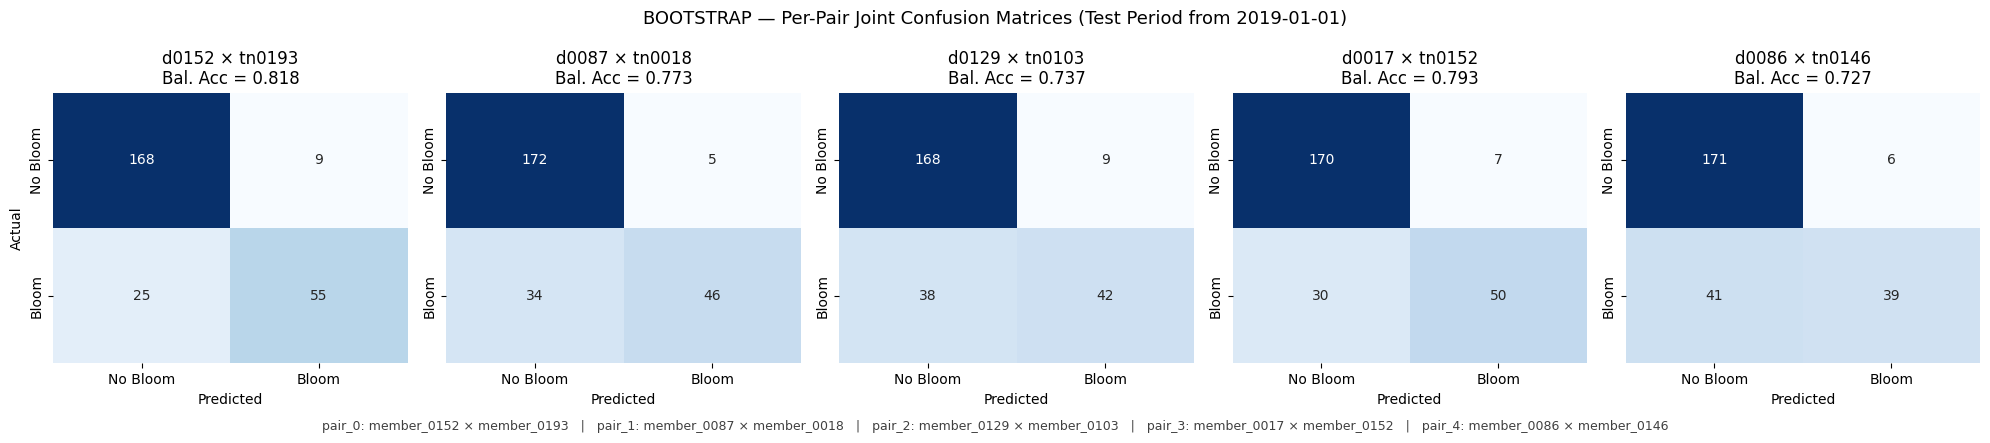

Saved: output\joint\figures\glue_joint_member_cms.png


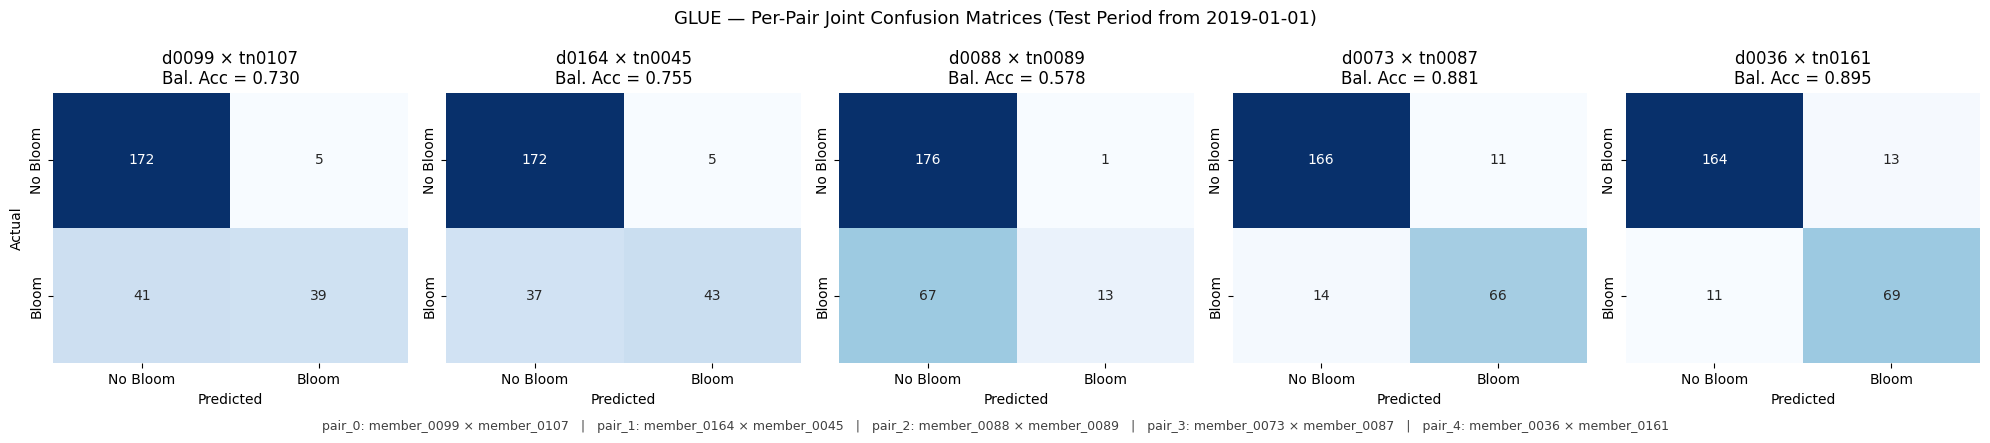

Saved: output\joint\figures\enkf_joint_member_cms.png


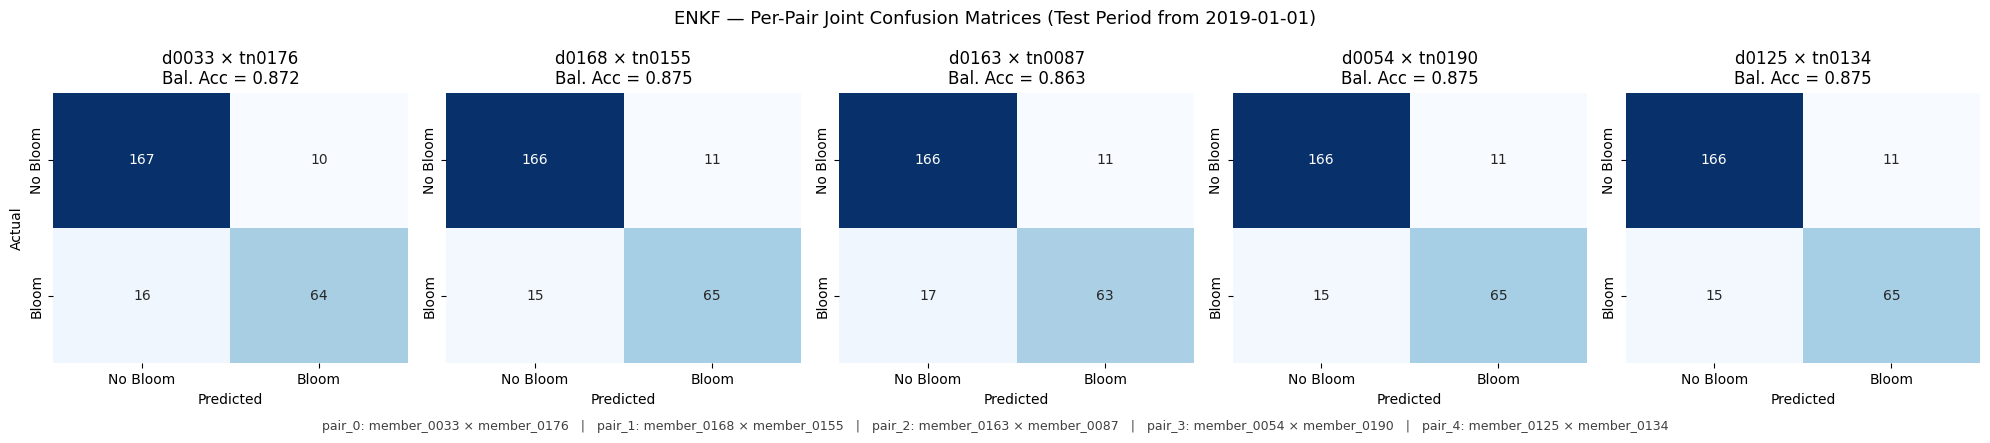

Saved: output\joint\figures\lpu_joint_member_cms.png


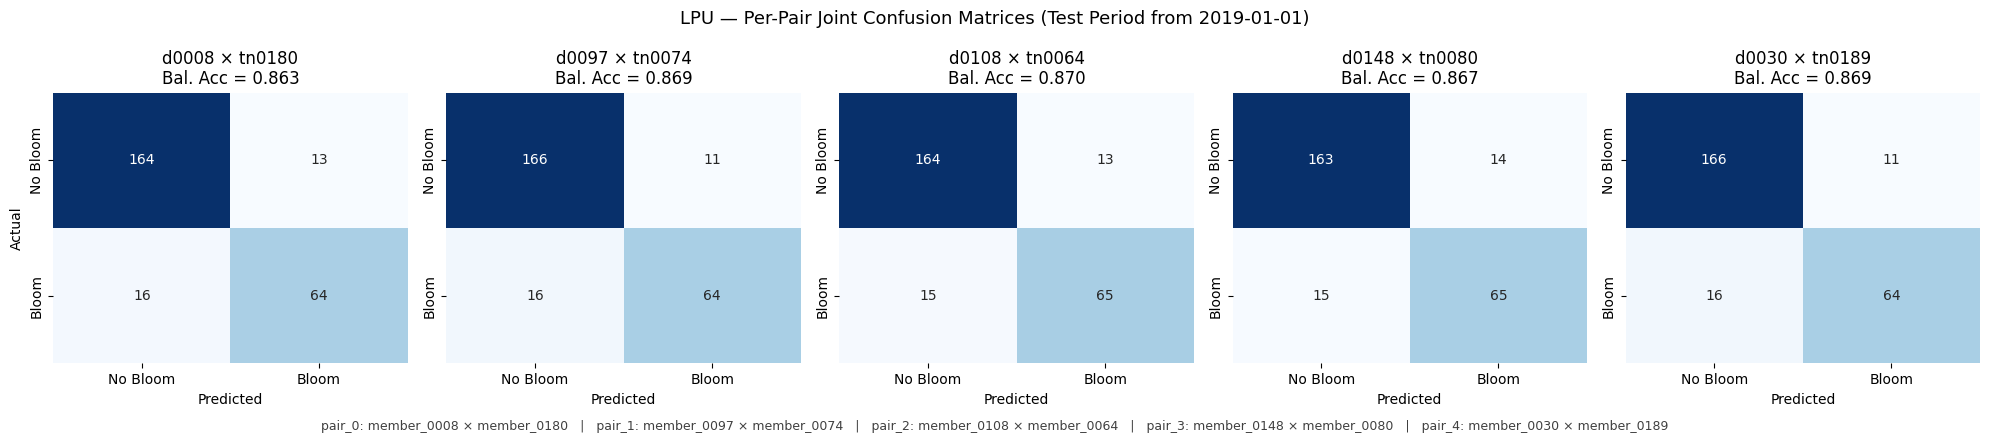

In [5]:
# === Cell B: Per-method joint-pair confusion-matrix grids ===
# source: adapted from discharge/notebooks/06_ensemble_member_inference.ipynb::plot_member_cms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, balanced_accuracy_score


def plot_joint_member_cms(method_name: str) -> None:
    """Plot 5 confusion matrices side-by-side for the 5 joint pairs of `method_name`.
    Uses test-period predictions only. title form, filename, caption,
    SAVE_OUTPUTS gating.
    """
    pred = pred_by_method[method_name]
    pair_idx = pair_index_by_method[method_name]                             # list[(d_idx, tn_idx)]
    pair_labels = [f"d{d:04d} \u00D7 tn{t:04d}" for d, t in pair_idx]        # (Unicode x)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
    for j, (label, ax) in enumerate(zip(pair_labels, axes)):
        y_pred_j = pred[j][test_mask_members]
        cm = confusion_matrix(y_test_members, y_pred_j, labels=[0, 1])
        bal_acc = balanced_accuracy_score(y_test_members, y_pred_j)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
            xticklabels=["No Bloom", "Bloom"],
            yticklabels=["No Bloom", "Bloom"],
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual" if j == 0 else "")
        ax.set_title(f"{label}\nBal. Acc = {bal_acc:.3f}")

    fig.suptitle(
        f"{method_name.upper()} \u2014 Per-Pair Joint Confusion Matrices "
        f"(Test Period from {TEST_CUTOFF})",
        fontsize=13,
    )

    # caption below the grid mapping pair index -> full member_XXXX names
    caption_lines = [
        f"pair_{i}: member_{d:04d} \u00D7 member_{t:04d}"
        for i, (d, t) in enumerate(pair_idx)
    ]
    fig.text(0.5, -0.02, "   |   ".join(caption_lines),
             ha="center", fontsize=9, color="0.25")

    plt.tight_layout()
    if SAVE_OUTPUTS:
        fname = FIGURES_DIR / f"{method_name}_joint_member_cms.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {fname}")
    plt.show()


for method in METHODS:
    plot_joint_member_cms(method)


Saved: output\joint\figures\joint_comparison_cm.png


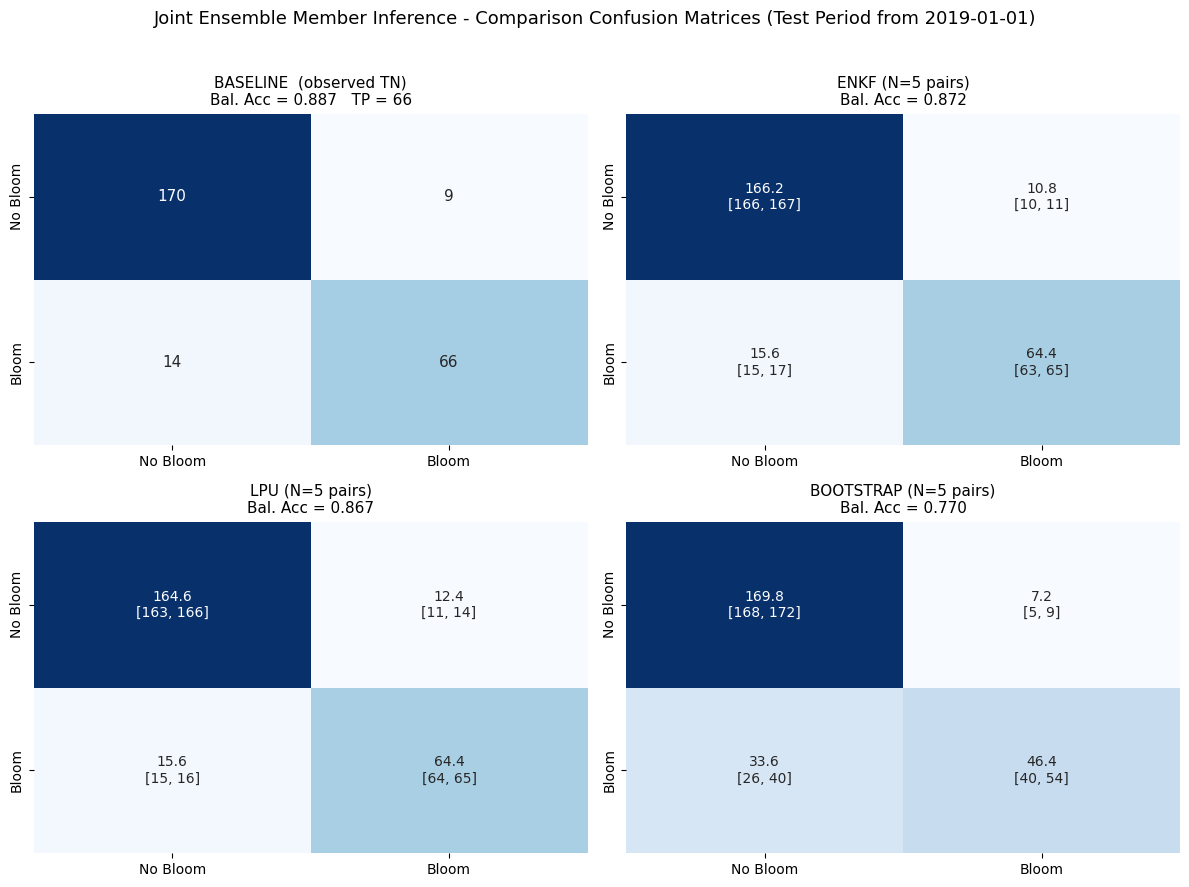

In [6]:
# === Cell C: Comparison CM - baseline + 3 ranked methods ===
# source: adapted from discharge/notebooks/06_ensemble_member_inference.ipynb cell_final_cm_code
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# --- Rank methods by mean TP across their 5 joint pairs ---
method_mean_tp = {}
for method in METHODS:
    cms = np.stack([
        confusion_matrix(
            y_test_members,
            pred_by_method[method][j][test_mask_members],
            labels=[0, 1],
        )
        for j in range(N_PAIRS_PER_METHOD)
    ])
    method_mean_tp[method] = cms.mean(axis=0)[1, 1]

ranked_methods = sorted(METHODS, key=lambda m: method_mean_tp[m], reverse=True)

# --- Figure scaffolding: baseline top-left, top 3 ranked methods filling remaining slots ---
fig = plt.figure(figsize=(12, 9))
gs = gridspec.GridSpec(2, 2, figure=fig)
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
ax_bl = fig.add_subplot(gs[positions[0]])

# --- Baseline cell: recomputed CM from baseline_pred[test_mask_baseline] ---
cm_baseline = confusion_matrix(
    y_test_baseline, baseline_pred[test_mask_baseline], labels=[0, 1]
)
bal_acc_bl = balanced_accuracy_score(
    y_test_baseline, baseline_pred[test_mask_baseline]
)
tp_bl = int(cm_baseline[1, 1])
annot_bl = np.array(
    [[str(int(cm_baseline[i, k])) for k in range(2)] for i in range(2)]
)
sns.heatmap(
    cm_baseline, annot=annot_bl, fmt="", cmap="Blues",
    ax=ax_bl, cbar=False,
    xticklabels=["No Bloom", "Bloom"],
    yticklabels=["No Bloom", "Bloom"],
    annot_kws={"size": 11},
)
ax_bl.set_title(
    f"BASELINE  (observed TN)\nBal. Acc = {bal_acc_bl:.3f}   TP = {tp_bl}",
    fontsize=11,
)

# --- Method cells: mean [p05, p95] annotations, title "{METHOD} (N=5 pairs)" ---
for slot, method in enumerate(ranked_methods[:3], start=1):
    ax_m = fig.add_subplot(gs[positions[slot]])
    cms = np.stack([
        confusion_matrix(
            y_test_members,
            pred_by_method[method][j][test_mask_members],
            labels=[0, 1],
        )
        for j in range(N_PAIRS_PER_METHOD)
    ])
    cm_mean = cms.mean(axis=0)
    cm_p05 = np.percentile(cms, 5, axis=0)
    cm_p95 = np.percentile(cms, 95, axis=0)

    annot = np.empty_like(cm_mean, dtype=object)
    for i in range(2):
        for k in range(2):
            annot[i, k] = (
                f"{cm_mean[i, k]:.1f}\n"
                f"[{cm_p05[i, k]:.0f}, {cm_p95[i, k]:.0f}]"
            )

    bal_accs = [
        balanced_accuracy_score(
            y_test_members,
            pred_by_method[method][j][test_mask_members],
        )
        for j in range(N_PAIRS_PER_METHOD)
    ]
    bal_acc_mean = float(np.mean(bal_accs))

    sns.heatmap(
        cm_mean, annot=annot, fmt="", cmap="Blues",
        ax=ax_m, cbar=False,
        xticklabels=["No Bloom", "Bloom"],
        yticklabels=["No Bloom", "Bloom"],
        annot_kws={"size": 10},
    )
    ax_m.set_title(
        f"{method.upper()} (N=5 pairs)\nBal. Acc = {bal_acc_mean:.3f}",
        fontsize=11,
    )

fig.suptitle(
    f"Joint Ensemble Member Inference - Comparison Confusion Matrices "
    f"(Test Period from {TEST_CUTOFF})",
    fontsize=13,
)
plt.tight_layout(rect=(0, 0, 1, 0.96))

if SAVE_OUTPUTS:
    fname = FIGURES_DIR / "joint_comparison_cm.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")
plt.show()


Saved: output\joint\figures\joint_members_pr.png


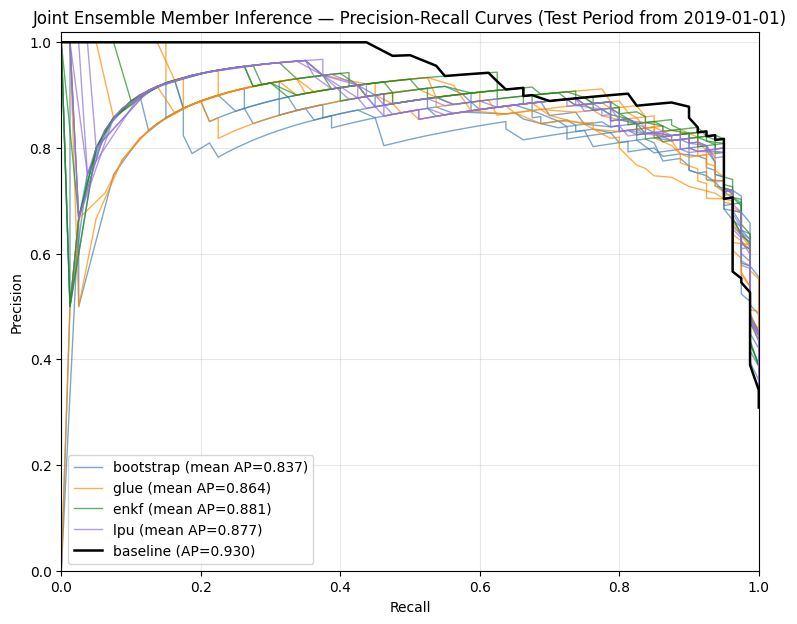

In [7]:
# === Cell D: Precision-recall curves ===
# source: adapted from discharge/notebooks/06_ensemble_member_inference.ipynb::cell_pr_code
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(9, 7))

for method in METHODS:
    color = METHOD_COLORS[method]
    aps = []
    for j in range(N_PAIRS_PER_METHOD):
        proba_j = proba_by_method[method][j][test_mask_members]
        prec, rec, _ = precision_recall_curve(y_test_members, proba_j)
        ap = average_precision_score(y_test_members, proba_j)
        aps.append(ap)
        label = (
            f"{method} (mean AP={np.mean(aps):.3f})"
            if j == N_PAIRS_PER_METHOD - 1
            else None
        )
        ax.plot(rec, prec, color=color, linewidth=1.0, alpha=0.7, label=label)

# Baseline on top
prec_bl, rec_bl, _ = precision_recall_curve(
    y_test_baseline, baseline_proba[test_mask_baseline]
)
ap_bl = average_precision_score(
    y_test_baseline, baseline_proba[test_mask_baseline]
)
ax.plot(
    rec_bl, prec_bl, color="black", linewidth=1.8,
    label=f"baseline (AP={ap_bl:.3f})", zorder=10,
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    f"Joint Ensemble Member Inference — Precision-Recall Curves "
    f"(Test Period from {TEST_CUTOFF})",
    fontsize=12,
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left", fontsize=10)

if SAVE_OUTPUTS:
    fname = FIGURES_DIR / "joint_members_pr.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")
plt.show()


Saved: output\joint\figures\joint_traces_full.png


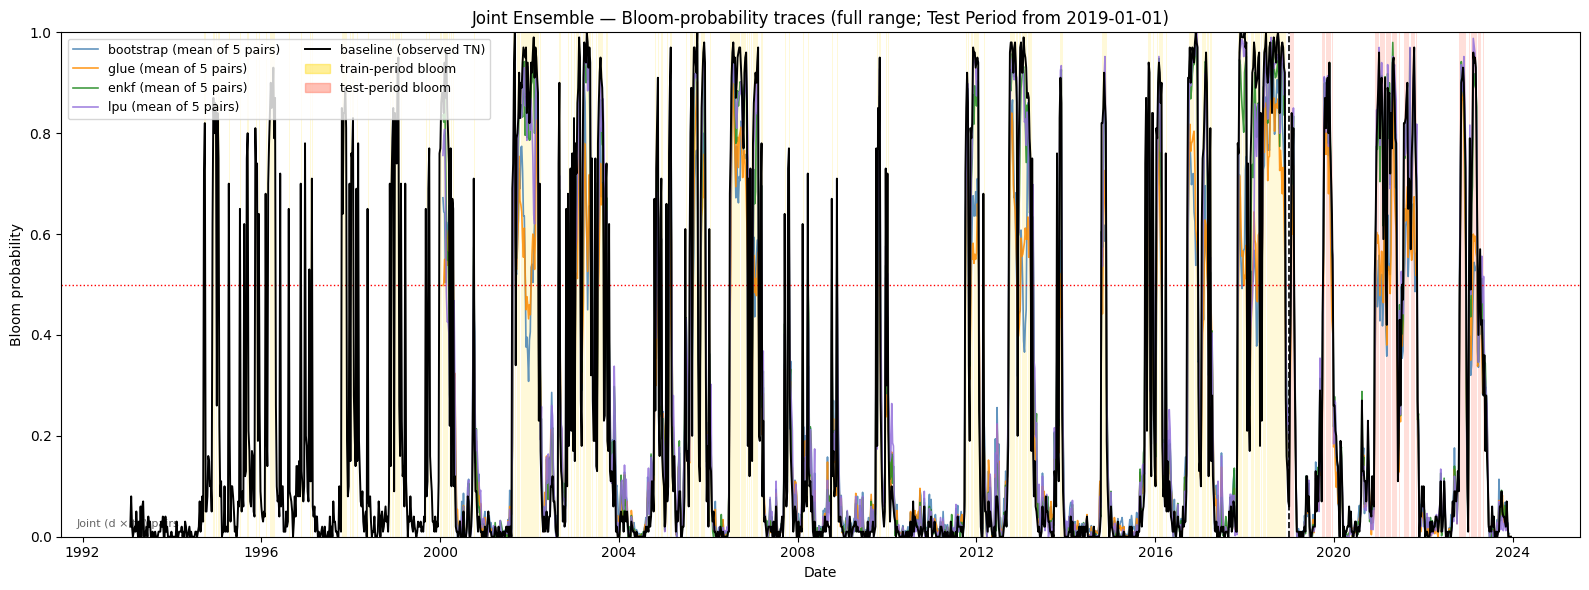

In [8]:
# === Cell E: Full-range bloom-probability traces ===
# source: adapted from discharge/notebooks/06_ensemble_member_inference.ipynb::cell_traces_code
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# observed bloom dates from OBS_CSV, kb >= 100_000
obs_bloom = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time")
bloom_dates = obs_bloom.index[obs_bloom["kb"] >= 100_000]
bloom_train = bloom_dates[bloom_dates <  pd.Timestamp(TEST_CUTOFF)]
bloom_test  = bloom_dates[bloom_dates >= pd.Timestamp(TEST_CUTOFF)]
half_week   = pd.Timedelta(days=3)

fig, ax = plt.subplots(figsize=(16, 6))

# Gold (train) + tomato (test) axvspans
for bd in bloom_train:
    ax.axvspan(bd - half_week, bd + half_week,
               color="gold", alpha=0.15, linewidth=0)
for bd in bloom_test:
    ax.axvspan(bd - half_week, bd + half_week,
               color="tomato", alpha=0.20, linewidth=0)

# Method mean probability lines
for method in METHODS:
    mean_proba = proba_by_method[method].mean(axis=0)
    ax.plot(aligned_index, mean_proba,
            color=METHOD_COLORS[method], linewidth=1.2, alpha=0.85,
            label=f"{method} (mean of {N_PAIRS_PER_METHOD} pairs)")

# Baseline on top
ax.plot(baseline_dates, baseline_proba,
        color="black", linewidth=1.4, label="baseline (observed TN)", zorder=5)

# Cutoff + 0.5 reference
ax.axvline(pd.Timestamp(TEST_CUTOFF),
           color="black", linestyle="--", linewidth=1.2)
ax.axhline(0.5, color="red", linestyle=":", linewidth=1.0)

ax.set_xlabel("Date")
ax.set_ylabel("Bloom probability")
ax.set_ylim(0, 1)
ax.set_title(
    f"Joint Ensemble — Bloom-probability traces (full range; "
    f"Test Period from {TEST_CUTOFF})",
    fontsize=12,
)

# Extend legend with bloom-span patches
handles, labels = ax.get_legend_handles_labels()
handles.extend([
    mpatches.Patch(color="gold",   alpha=0.4, label="train-period bloom"),
    mpatches.Patch(color="tomato", alpha=0.4, label="test-period bloom"),
])
ax.legend(handles=handles, loc="upper left", fontsize=9, ncol=2)

ax.text(0.01, 0.02, "Joint (d × tn) pairs",
        transform=ax.transAxes, fontsize=8, color="0.4")

plt.tight_layout()
if SAVE_OUTPUTS:
    fname = FIGURES_DIR / "joint_traces_full.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")
plt.show()


Saved: output\joint\figures\joint_traces_test.png


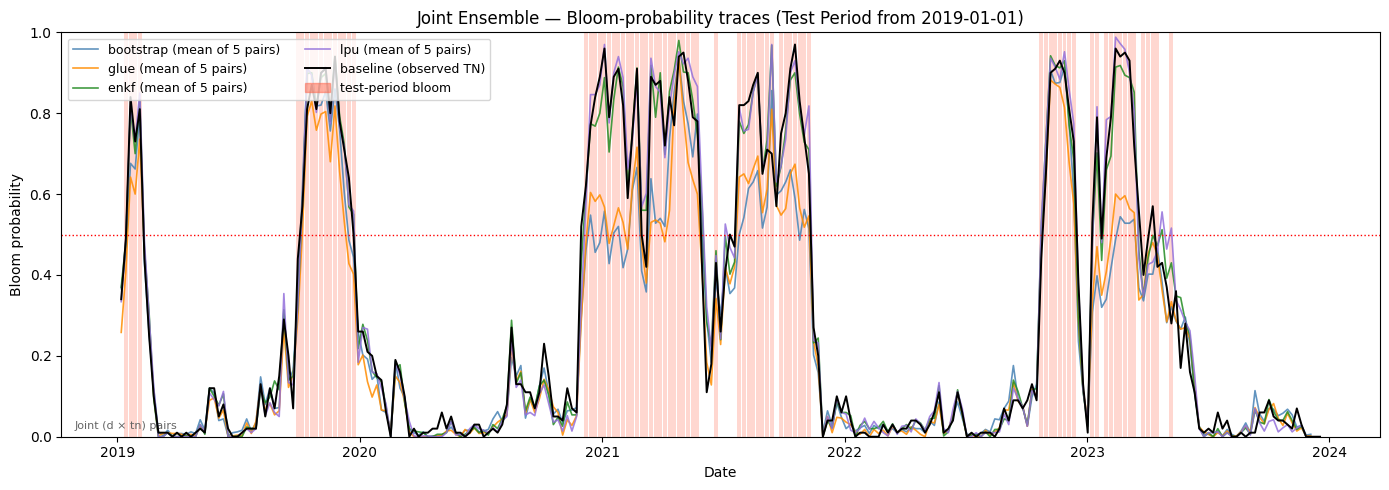

In [9]:
# === Cell F: Test-period zoom bloom-probability traces ===
# source: adapted from discharge/notebooks/06_ensemble_member_inference.ipynb::cell_zoom_code
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

obs_bloom = pd.read_csv(OBS_CSV, parse_dates=["time"], index_col="time")
bloom_dates = obs_bloom.index[obs_bloom["kb"] >= 100_000]
bloom_test  = bloom_dates[bloom_dates >= pd.Timestamp(TEST_CUTOFF)]
half_week   = pd.Timedelta(days=3)

fig, ax = plt.subplots(figsize=(14, 5))

# Tomato axvspans ONLY ( no gold, no cutoff line)
for bd in bloom_test:
    ax.axvspan(bd - half_week, bd + half_week,
               color="tomato", alpha=0.25, linewidth=0)

# Method mean lines, sliced by test_mask_members
for method in METHODS:
    mean_proba = proba_by_method[method].mean(axis=0)
    ax.plot(
        aligned_index[test_mask_members], mean_proba[test_mask_members],
        color=METHOD_COLORS[method], linewidth=1.2, alpha=0.85,
        label=f"{method} (mean of {N_PAIRS_PER_METHOD} pairs)",
    )

# Baseline, sliced by test_mask_baseline
ax.plot(
    baseline_dates[test_mask_baseline], baseline_proba[test_mask_baseline],
    color="black", linewidth=1.4, label="baseline (observed TN)", zorder=5,
)

ax.axhline(0.5, color="red", linestyle=":", linewidth=1.0)

ax.set_xlabel("Date")
ax.set_ylabel("Bloom probability")
ax.set_ylim(0, 1)
ax.set_title(
    f"Joint Ensemble — Bloom-probability traces (Test Period from {TEST_CUTOFF})",
    fontsize=12,
)

handles, labels = ax.get_legend_handles_labels()
handles.append(
    mpatches.Patch(color="tomato", alpha=0.5, label="test-period bloom")
)
ax.legend(handles=handles, loc="upper left", fontsize=9, ncol=2)

ax.text(0.01, 0.02, "Joint (d × tn) pairs",
        transform=ax.transAxes, fontsize=8, color="0.4")

plt.tight_layout()
if SAVE_OUTPUTS:
    fname = FIGURES_DIR / "joint_traces_test.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")
plt.show()


In [10]:
# === Cell G: Joint probability CSV export ===
# source: adapted from discharge/notebooks/06_ensemble_member_inference.ipynb::cell_export_code
import pandas as pd

if SAVE_OUTPUTS:
    series_dict = {
        "baseline": pd.Series(baseline_proba, index=baseline_dates, name="baseline"),
    }
    # METHODS iteration order drives column order (bootstrap→glue→enkf→lpu)
    for method in METHODS:
        for j, (d_idx, tn_idx) in enumerate(pair_index_by_method[method]):
            col = f"{method}_d{d_idx:04d}_tn{tn_idx:04d}"                 # naming
            series_dict[col] = pd.Series(
                proba_by_method[method][j],
                index=aligned_index,
                name=col,
            )

    # outer-join by timestamp — handles aligned_index vs baseline_dates mismatch
    proba_df = pd.DataFrame(series_dict)
    proba_df.index.name = "date"

    # A2: defensive mkdir — CSV_DIR may not have been created in cell 2
    CSV_DIR.mkdir(parents=True, exist_ok=True)

    # seed IS in the CSV filename (unlike figures —
    proba_csv = CSV_DIR / f"joint_proba_seed{PAIRING_SEED}.csv"
    proba_df.to_csv(proba_csv)
    print(f"Saved: {proba_csv}  shape={proba_df.shape}")
else:
    print("SAVE_OUTPUTS is False — skipping CSV export.")


Saved: output\joint\csv\joint_proba_seed42.csv  shape=(1613, 21)
